In [1]:
!pip install segmentation-models-pytorch albumentations pycocotools -q
# ============================================================
# CELL 2 — Imports & Constants
# ============================================================
import os, cv2, json, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import albumentations as A

from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS     = 20
BATCH_SIZE = 4
LR         = 1e-4
PATIENCE   = 4
IMG_SIZE   = 512
AUG_MULTIPLIER = 4   # 102 images × 4 = 408 samples per epoch

TRAIN_DIR = "/kaggle/input/datasets/alitawfiq/hieroglyphics-translation-coco-format/segmentation.v1i.coco-segmentation/train"
VAL_DIR   = "/kaggle/input/datasets/alitawfiq/hieroglyphics-translation-coco-format/segmentation.v1i.coco-segmentation/valid"
TEST_DIR  = "/kaggle/input/datasets/alitawfiq/hieroglyphics-translation-coco-format/segmentation.v1i.coco-segmentation/test"

print(f"Device: {DEVICE}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 1.2 MB/s eta 0:00:00a 0:00:01
Device: cuda


In [2]:
def preprocess_image(image_path: str):
    img = cv2.imread(image_path)
    if img is None:
        return None, None
    raw_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    img = cv2.GaussianBlur(img, (3, 3), 0)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    proc = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)
    return raw_pil, Image.fromarray(proc)


In [3]:
class COCOSegmentationDataset(Dataset):
    def __init__(self, data_dir, augment=False, multiplier=1):
        self.data_dir   = data_dir
        self.augment    = augment
        self.multiplier = multiplier

        ann_path  = os.path.join(data_dir, "_annotations.coco.json")
        self.coco = COCO(ann_path)
        self.ids  = list(self.coco.imgs.keys())

        # ── augmentation transforms (applied on top of resize) ──
        self.aug_transform = A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.Rotate(limit=20, p=0.5),
            A.RandomBrightnessContrast(
                brightness_limit=0.3,
                contrast_limit=0.3,
                p=0.5
            ),
            A.GaussNoise(p=0.3),
            A.ElasticTransform(p=0.2)
                
        ])

        # ── val/test — resize only ──
        self.val_transform = A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
        ])

    def __len__(self):
        return len(self.ids) * self.multiplier

    def __getitem__(self, idx):
        # multiplier maps idx back to a real image index
        actual_idx = idx % len(self.ids)
        img_id     = self.ids[actual_idx]

        img_info = self.coco.loadImgs(img_id)[0]
        path     = os.path.join(self.data_dir, img_info['file_name'])

        _, proc_pil = preprocess_image(path)
        if proc_pil is None:
            return self.__getitem__((idx + 1) % len(self))

        image = np.array(proc_pil)   # already Gaussian + CLAHE

        # build combined binary mask from all annotations
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns    = self.coco.loadAnns(ann_ids)
        mask    = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        for ann in anns:
            m    = self.coco.annToMask(ann)
            mask = np.maximum(mask, m)

        # apply transforms
        if self.augment:
            out   = self.aug_transform(image=image, mask=mask)
        else:
            out   = self.val_transform(image=image, mask=mask)

        image = out['image']
        mask  = out['mask']

        image = torch.tensor(image / 255.0).permute(2, 0, 1).float()
        mask  = torch.tensor(mask).unsqueeze(0).float()

        return image, mask


def custom_collate(batch):
    batch = [b for b in batch if b is not None]
    if not batch:
        return None
    return torch.utils.data.dataloader.default_collate(batch)

In [4]:
train_ds = COCOSegmentationDataset(TRAIN_DIR, augment=True,  multiplier=AUG_MULTIPLIER)
val_ds   = COCOSegmentationDataset(VAL_DIR,   augment=False, multiplier=1)
test_ds  = COCOSegmentationDataset(TEST_DIR,  augment=False, multiplier=1)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=custom_collate)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=custom_collate)
test_loader  = DataLoader(test_ds,  batch_size=1,
                          shuffle=False, collate_fn=custom_collate)

print(f"Train: {len(train_ds)} ({len(train_ds)//AUG_MULTIPLIER} base × {AUG_MULTIPLIER})")
print(f"Val  : {len(val_ds)}")
print(f"Test : {len(test_ds)}")



loading annotations into memory...
Done (t=0.25s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Train: 408 (102 base × 4)
Val  : 10
Test : 7


In [5]:
model = smp.Unet(
    encoder_name    = "resnet34",        # same encoder you had
    encoder_weights = "imagenet",        # pretrained
    in_channels     = 3,
    classes         = 1,                 # binary segmentation
    activation      = None,              # raw logits — BCEWithLogitsLoss handles sigmoid
).to(DEVICE)


total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")



config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Total params    : 24,436,369
Trainable params: 24,436,369


In [6]:
class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=0.3, dice_weight=0.7):
        super().__init__()
        self.bce        = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

    def forward(self, pred, target):
        bce  = self.bce(pred, target)
        p    = torch.sigmoid(pred)
        inter = (p * target).sum(dim=(-2, -1))
        denom = p.sum(dim=(-2, -1)) + target.sum(dim=(-2, -1))
        dice  = 1 - (2 * inter + 1) / (denom + 1)
        return self.bce_weight * bce + self.dice_weight * dice.mean()


criterion = DiceBCELoss()


In [7]:
def compute_iou(pred, target):
    with torch.no_grad():
        pred_bin = (torch.sigmoid(pred) > 0.5).float()
        inter    = (pred_bin * target).sum(dim=(-2, -1))
        union    = (pred_bin + target).clamp(0, 1).sum(dim=(-2, -1))
        return ((inter + 1e-6) / (union + 1e-6)).mean().item()


def compute_pixel_accuracy(pred, target):
    with torch.no_grad():
        pred_bin = (torch.sigmoid(pred) > 0.5).float()
        return (pred_bin == target).float().mean().item()


In [8]:
class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        bce = self.bce(pred, target)

        pred = torch.sigmoid(pred)
        inter = (pred * target).sum()
        dice = (2*inter + 1) / (pred.sum() + target.sum() + 1)

        return 0.5*bce + 0.5*(1-dice)

def compute_iou(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    inter = (pred * target).sum()
    union = (pred + target).clamp(0,1).sum()
    return (inter + 1e-6) / (union + 1e-6)

In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-7
)
scaler = torch.amp.GradScaler('cuda')


In [10]:
best_iou  = 0.0
counter   = 0
os.makedirs("unet_best", exist_ok=True)

history = {
    "train_loss": [], "val_loss": [],
    "train_iou":  [], "val_iou":  [],
    "train_acc":  [], "val_acc":  [],
}

for epoch in range(EPOCHS):

    # ── TRAIN ──────────────────────────────────────────────
    model.train()
    train_loss = train_iou = train_acc = n = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for batch in pbar:
        if batch is None:
            continue
        imgs, masks = batch
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            preds = model(imgs)
            if preds.shape != masks.shape:
                preds = F.interpolate(preds, size=masks.shape[-2:],
                                      mode='bilinear', align_corners=False)
            loss = criterion(preds, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_iou  += compute_iou(preds.detach(), masks)
        train_acc  += compute_pixel_accuracy(preds.detach(), masks)
        n          += 1

        pbar.set_postfix({
            "loss": f"{train_loss/n:.4f}",
            "IoU":  f"{train_iou/n:.4f}",
        })

    scheduler.step()

    # ── VALIDATION ─────────────────────────────────────────
    model.eval()
    val_loss = val_iou = val_acc = nv = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]",
                          leave=False):
            if batch is None:
                continue
            imgs, masks = batch
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

            with torch.amp.autocast('cuda'):
                preds = model(imgs)
                if preds.shape != masks.shape:
                    preds = F.interpolate(preds, size=masks.shape[-2:],
                                          mode='bilinear', align_corners=False)
                loss = criterion(preds, masks)

            val_loss += loss.item()
            val_iou  += compute_iou(preds, masks)
            val_acc  += compute_pixel_accuracy(preds, masks)
            nv       += 1

    # ── LOG ────────────────────────────────────────────────
    tl = train_loss / max(n,  1)
    ti = train_iou  / max(n,  1)
    ta = train_acc  / max(n,  1)
    vl = val_loss   / max(nv, 1)
    vi = val_iou    / max(nv, 1)
    va = val_acc    / max(nv, 1)

    history["train_loss"].append(tl)
    history["val_loss"].append(vl)
    history["train_iou"].append(ti)
    history["val_iou"].append(vi)
    history["train_acc"].append(ta)
    history["val_acc"].append(va)

    print(f"\n--- Epoch {epoch+1} ---")
    print(f"  Train  loss={tl:.4f}  IoU={ti:.4f}  Acc={ta:.4f}")
    print(f"  Val    loss={vl:.4f}  IoU={vi:.4f}  Acc={va:.4f}")

    if vi > best_iou:
        best_iou = vi
        counter  = 0
        torch.save(model.state_dict(), "unet_best/model.pt")
        print(f"  ⭐ Best IoU {best_iou:.4f} — model saved.")
    else:
        counter += 1
        print(f"  No improvement ({counter}/{PATIENCE})")
        if counter >= PATIENCE:
            print("  Early stopping.")
            break

print(f"\nDone. Best Val IoU: {best_iou:.4f}")

Epoch 1/20 [Train]: 100%|██████████| 102/102 [01:37<00:00,  1.04it/s, loss=0.5016, IoU=0.4397]



--- Epoch 1 ---
  Train  loss=0.5016  IoU=0.4397  Acc=0.7164
  Val    loss=0.4108  IoU=0.5338  Acc=0.7715
  ⭐ Best IoU 0.5338 — model saved.


Epoch 2/20 [Train]: 100%|██████████| 102/102 [01:36<00:00,  1.06it/s, loss=0.3903, IoU=0.5435]



--- Epoch 2 ---
  Train  loss=0.3903  IoU=0.5435  Acc=0.8068
  Val    loss=0.3473  IoU=0.5910  Acc=0.8260
  ⭐ Best IoU 0.5910 — model saved.


Epoch 3/20 [Train]: 100%|██████████| 102/102 [01:37<00:00,  1.05it/s, loss=0.3558, IoU=0.5719]


...


--- Epoch 10 ---
  Train  loss=0.2647  IoU=0.6621  Acc=0.8749
  Val    loss=0.2965  IoU=0.6242  Acc=0.8549
  No improvement (2/4)


Epoch 11/20 [Train]: 100%|██████████| 102/102 [01:36<00:00,  1.06it/s, loss=0.2586, IoU=0.6666]



--- Epoch 11 ---
  Train  loss=0.2586  IoU=0.6666  Acc=0.8774
  Val    loss=0.2959  IoU=0.6274  Acc=0.8535
  No improvement (3/4)


Epoch 12/20 [Train]: 100%|██████████| 102/102 [01:37<00:00,  1.05it/s, loss=0.2511, IoU=0.6757]
                                                                


--- Epoch 12 ---
  Train  loss=0.2511  IoU=0.6757  Acc=0.8820
  Val    loss=0.2946  IoU=0.6262  Acc=0.8605
  No improvement (4/4)
  Early stopping.

Done. Best Val IoU: 0.6290


Testing:  14%|█▍        | 1/7 [00:00<00:01,  3.27it/s]

  sample   1  IoU: 0.7351  Acc: 0.9109


Testing:  29%|██▊       | 2/7 [00:00<00:01,  3.53it/s]

  sample   2  IoU: 0.6554  Acc: 0.8728
  sample   3  IoU: 0.3611  Acc: 0.8061


Testing:  71%|███████▏  | 5/7 [00:00<00:00,  5.91it/s]

  sample   4  IoU: 0.6725  Acc: 0.8687
  sample   5  IoU: 0.6593  Acc: 0.8703


Testing: 100%|██████████| 7/7 [00:01<00:00,  5.26it/s]

  sample   6  IoU: 0.5948  Acc: 0.7913
  sample   7  IoU: 0.5996  Acc: 0.8451

  Test images : 7
  Mean IoU    : 0.6111
  Mean Acc    : 0.8522


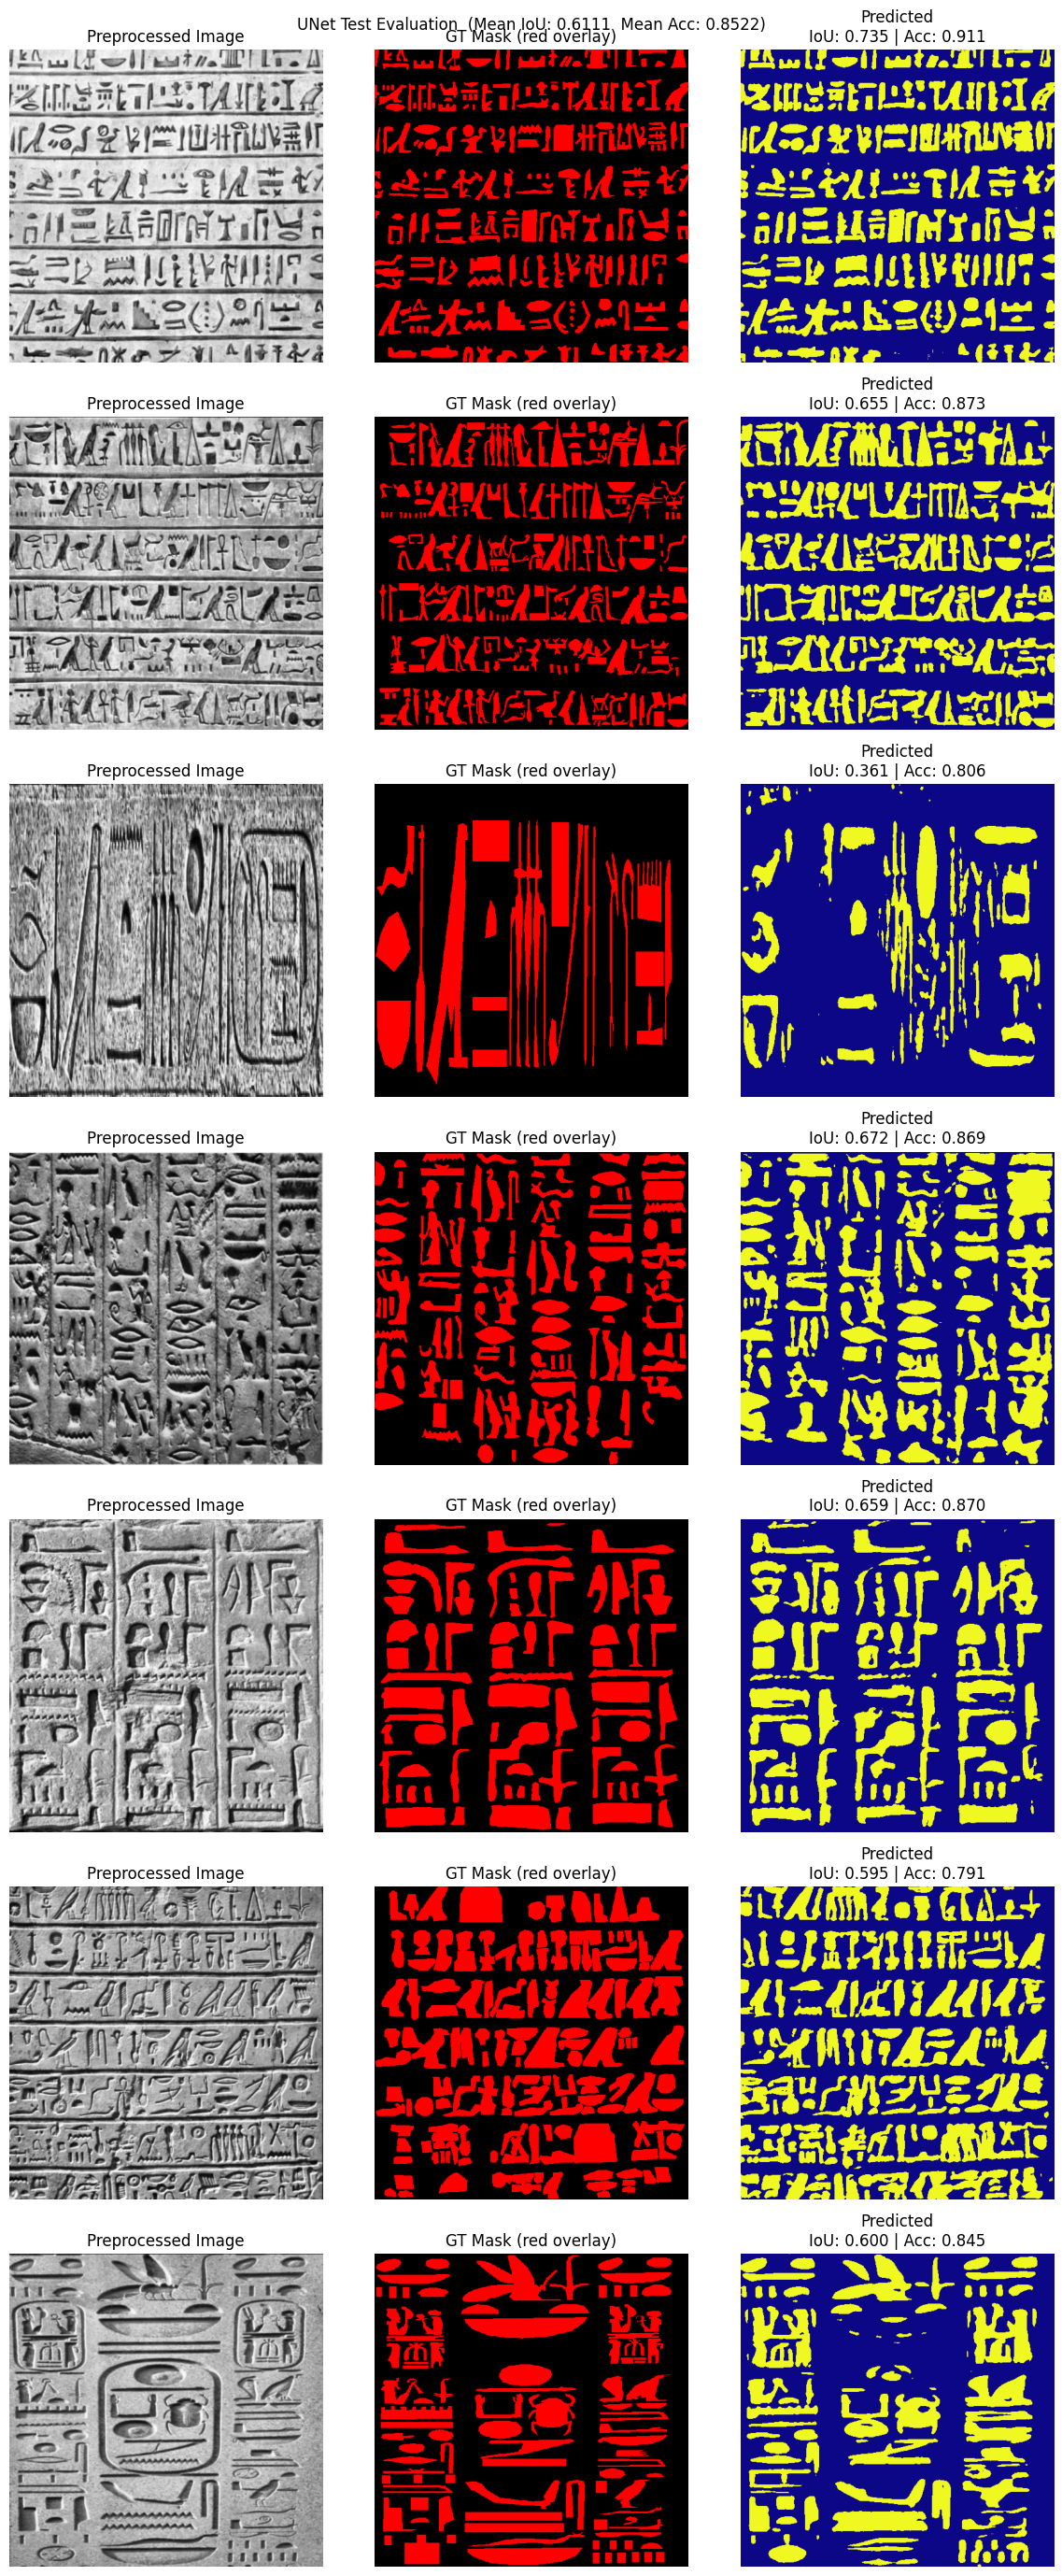

In [11]:
# ============================================================
# CELL 10 — Test Evaluation
# ============================================================
model.load_state_dict(torch.load("unet_best/model.pt", map_location=DEVICE))
model.eval()

test_iou = test_acc = n_test = 0
viz_data = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        if batch is None:
            continue
        imgs, masks = batch
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        preds = model(imgs)
        if preds.shape != masks.shape:
            preds = F.interpolate(preds, size=masks.shape[-2:],
                                  mode='bilinear', align_corners=False)

        iou = compute_iou(preds, masks)
        acc = compute_pixel_accuracy(preds, masks)

        test_iou += iou
        test_acc += acc
        n_test   += 1

        print(f"  sample {n_test:>3}  IoU: {iou:.4f}  Acc: {acc:.4f}")

        if len(viz_data) < 7:
            img_display = imgs[0].permute(1, 2, 0).cpu().numpy()
            img_display = (img_display - img_display.min()) / \
                          (img_display.max() - img_display.min() + 1e-6)

            gt_np   = masks[0, 0].cpu().numpy()
            pred_np = (torch.sigmoid(preds[0, 0]) > 0.5).float().cpu().numpy()

            gt_display         = np.zeros((*gt_np.shape, 3), dtype=np.uint8)
            gt_display[..., 0] = (gt_np > 0) * 255

            viz_data.append({
                "image":   img_display,
                "gt":      gt_display,
                "pred":    pred_np,
                "iou":     iou,
                "acc":     acc,
            })

mean_iou = test_iou / max(n_test, 1)
mean_acc = test_acc / max(n_test, 1)

print(f"\n{'='*40}")
print(f"  Test images : {n_test}")
print(f"  Mean IoU    : {mean_iou:.4f}")
print(f"  Mean Acc    : {mean_acc:.4f}")
print(f"{'='*40}")

# ── visualize ──
fig, axes = plt.subplots(len(viz_data), 3, figsize=(12, 4 * len(viz_data)))
if len(viz_data) == 1:
    axes = [axes]

for i, d in enumerate(viz_data):
    axes[i][0].imshow(d["image"])
    axes[i][0].set_title("Preprocessed Image")
    axes[i][0].axis("off")

    axes[i][1].imshow(d["gt"])
    axes[i][1].set_title("GT Mask (red overlay)")
    axes[i][1].axis("off")

    axes[i][2].imshow(d["pred"], cmap="plasma")
    axes[i][2].set_title(f"Predicted\nIoU: {d['iou']:.3f} | Acc: {d['acc']:.3f}")
    axes[i][2].axis("off")

plt.suptitle(f"UNet Test Evaluation  "
             f"(Mean IoU: {mean_iou:.4f}  Mean Acc: {mean_acc:.4f})",
             fontsize=12)
plt.tight_layout()
plt.show()